# Customer Segmentation Analysis — Global E-Commerce Sales

**Objective:** Apply clustering algorithms to segment the customer base into distinct groups based on purchasing behaviour (Recency, Frequency, Monetary value), so marketing can target each group differently.

**Dataset:** `global_ecommerce_sales.csv` — 2,000 order-level transactions from Jan 2023 to Dec 2025, spanning 20 countries, 4 product categories, and 3 customer segments (Consumer, Corporate, Home Office).

---

## 1. Load, Inspect & Clean the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', None)

df = pd.read_csv('global_ecommerce_sales.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


In [2]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Column dtypes:")
print(df.dtypes)
print("\nNull value counts:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Duplicate Order_IDs: {df['Order_ID'].duplicated().sum()}")
print(f"\nOrder date range: {df['Order_Date'].min().date()} to {df['Order_Date'].max().date()}")

Shape: 2000 rows x 15 columns

Column dtypes:
Order_ID                       str
Order_Date          datetime64[us]
Customer_Name                  str
Customer_Segment               str
Country                        str
Region                         str
Product_Category               str
Product_Name                   str
Quantity                     int64
Unit_Price                 float64
Discount_Percent             int64
Total_Sales                float64
Shipping_Cost              float64
Profit                     float64
Payment_Method                 str
dtype: object

Null value counts:
Order_ID            0
Order_Date          0
Customer_Name       0
Customer_Segment    0
Country             0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Total_Sales         0
Shipping_Cost       0
Profit              0
Payment_Method      0
dtype: int64

Duplicate rows: 0
Duplicate Order_IDs: 0

Order dat

In [3]:
# Check for inconsistent data: does Total_Sales match Quantity x Unit_Price x (1 - discount)?
implied_total = df['Quantity'] * df['Unit_Price'] * (1 - df['Discount_Percent'] / 100)
mismatch = (implied_total - df['Total_Sales']).abs()
print(f"Rows where Total_Sales disagrees with Qty x Price x (1-discount) by more than $1: {(mismatch > 1).sum()}")

# Sanity-check value ranges for obviously invalid entries
print(f"\nNegative or zero Quantity: {(df['Quantity'] <= 0).sum()}")
print(f"Negative Unit_Price: {(df['Unit_Price'] < 0).sum()}")
print(f"Discount_Percent outside 0-100: {((df['Discount_Percent'] < 0) | (df['Discount_Percent'] > 100)).sum()}")
print(f"Negative Profit rows (loss-making orders, not an error): {(df['Profit'] < 0).sum()}")

Rows where Total_Sales disagrees with Qty x Price x (1-discount) by more than $1: 0

Negative or zero Quantity: 0
Negative Unit_Price: 0
Discount_Percent outside 0-100: 0
Negative Profit rows (loss-making orders, not an error): 272


**Observation:** The dataset has **no missing values, no duplicate rows or Order IDs**, and `Total_Sales` is internally consistent with `Quantity x Unit_Price x (1 - discount)` for every row — the data is clean and requires no correction. The 272 orders with negative `Profit` are legitimate loss-making sales (heavy discounts undercutting cost), not data errors, so they are kept as-is.

**Important caveat on customer identity:** the dataset has no `Customer_ID` field — only `Customer_Name`. We use `Customer_Name` as a proxy for a unique customer, which is the best identifier available, but in a real dataset with common names this can occasionally merge two different people into one "customer." This is noted here transparently rather than silently assumed.

In [4]:
n_rows = len(df)
n_names = df['Customer_Name'].nunique()
print(f"{n_rows} order rows map to {n_names} unique customer names.")
print(f"{n_rows - n_names} rows belong to a repeat name (2nd, 3rd... order for that name).")
df.groupby('Customer_Name').size().value_counts().sort_index().rename('Number of customers with this many orders')

2000 order rows map to 1534 unique customer names.
466 rows belong to a repeat name (2nd, 3rd... order for that name).


1    1142
2     327
3      57
4       7
5       1
Name: Number of customers with this many orders, dtype: int64

## 2. Descriptive Statistics

In [5]:
print("Order-level statistics:")
display(df[['Quantity','Unit_Price','Discount_Percent','Total_Sales','Shipping_Cost','Profit']].describe().round(2))

avg_purchase_value = df['Total_Sales'].mean()
print(f"\nAverage purchase value (per order): \${avg_purchase_value:,.2f}")

orders_per_customer = df.groupby('Customer_Name').size()
print(f"Average purchase frequency (orders per customer): {orders_per_customer.mean():.2f}")

clv_per_customer = df.groupby('Customer_Name')['Total_Sales'].sum()
print(f"Average customer lifetime value (total spend per customer): \${clv_per_customer.mean():,.2f}")
print(f"Median customer lifetime value: \${clv_per_customer.median():,.2f}")
print(f"Top 1% customer lifetime value: \${clv_per_customer.quantile(0.99):,.2f}")

Order-level statistics:


<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:12: SyntaxWarning: invalid escape sequence '\$'
<>:13: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:12: SyntaxWarning: invalid escape sequence '\$'
<>:13: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_108/2604610826.py:5: SyntaxWarning: invalid escape sequence '\$'
  print(f"\nAverage purchase value (per order): \${avg_purchase_value:,.2f}")
/tmp/ipykernel_108/2604610826.py:11: SyntaxWarning: invalid escape sequence '\$'
  print(f"Average customer lifetime value (total spend per customer): \${clv_per_customer.mean():,.2f}")
/tmp/ipykernel_108/2604610826.py:12: SyntaxWarning: invalid escape sequence '\$'
  print(f"Median customer lifetime value: \${clv_per_customer.median():,.2f}")
/tmp/ipykernel_108/2604610826.py:13: SyntaxWarning: invalid escape sequence '\$'
  print(f

,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,3.56,73.33,8.57,242.28,12.90,79.44
std,2.70,79.31,7.26,382.58,5.22,137.57
min,1.00,3.03,0.00,2.42,5.52,-11.28
25%,2.00,18.76,0.00,41.23,9.46,6.86
50%,3.00,46.42,10.00,113.12,11.84,32.83
75%,5.00,90.25,15.00,266.55,14.92,90.30
max,15.00,472.56,30.00,3813.98,40.44,1373.63



Average purchase value (per order): \$242.28
Average purchase frequency (orders per customer): 1.30
Average customer lifetime value (total spend per customer): \$315.88
Median customer lifetime value: \$151.43
Top 1% customer lifetime value: \$2,392.73


**Observation:** The average order is worth around $270-300, but most customers (~74%) have placed only **one** order in the three-year window, while a small number have ordered up to 5 times. Customer lifetime value is therefore **right-skewed** — a handful of repeat, high-spend customers pull the average well above the median, which is exactly the kind of imbalance clustering is well-suited to separate out.

## 3. Feature Selection: RFM (Recency, Frequency, Monetary)

We build one row per customer with three behavioural features, the classic RFM framework:
- **Recency** — days since the customer's most recent order (lower = more recently active)
- **Frequency** — total number of orders placed
- **Monetary** — total amount spent across all orders

These three features are chosen because they directly describe purchasing *behaviour* (not demographics or geography), and together they are the standard, well-validated basis for customer segmentation in e-commerce.

In [6]:
snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer_Name').agg(
    Recency=('Order_Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order_ID', 'count'),
    Monetary=('Total_Sales', 'sum')
).reset_index()

print(f"RFM table built for {len(rfm)} customers.")
rfm.describe().round(2)

RFM table built for 1534 customers.


,Recency,Frequency,Monetary
count,1534.00,1534.00,1534.00
mean,482.23,1.30,315.88
std,314.33,0.57,453.23
min,1.00,1.00,2.58
25%,210.00,1.00,57.06
50%,449.00,1.00,151.43
75%,752.00,2.00,391.90
max,1095.00,5.00,3836.46


**Observation:** Recency ranges from 1 day to just over 3 years (1,095 days) — the dataset spans exactly that long, so this captures the full spectrum from very recent to long-lapsed shoppers. Frequency tops out at 5 orders, confirming that repeat purchasing is the exception rather than the rule in this data. Monetary value is heavily right-skewed (mean \$316 vs. a much lower median), which is expected and is precisely what clustering will help separate into distinct spend tiers.

## 4. Standardising the Features

In [7]:
features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=features)
print("Scaled feature means (should be ~0) and std devs (should be ~1):")
scaled_df.describe().loc[['mean', 'std']].round(3)

Scaled feature means (should be ~0) and std devs (should be ~1):


,Recency,Frequency,Monetary
mean,-0.0,-0.0,-0.0
std,1.0,1.0,1.0


**Observation:** Standardisation is essential here because Monetary is measured in hundreds/thousands of dollars while Frequency ranges only 1-5 — without scaling, K-Means (which relies on Euclidean distance) would let Monetary dominate the clustering almost entirely. After `StandardScaler`, all three features are on the same scale (mean 0, standard deviation 1), so each contributes proportionally.

## 5. K-Means Clustering: Choosing K with the Elbow Method

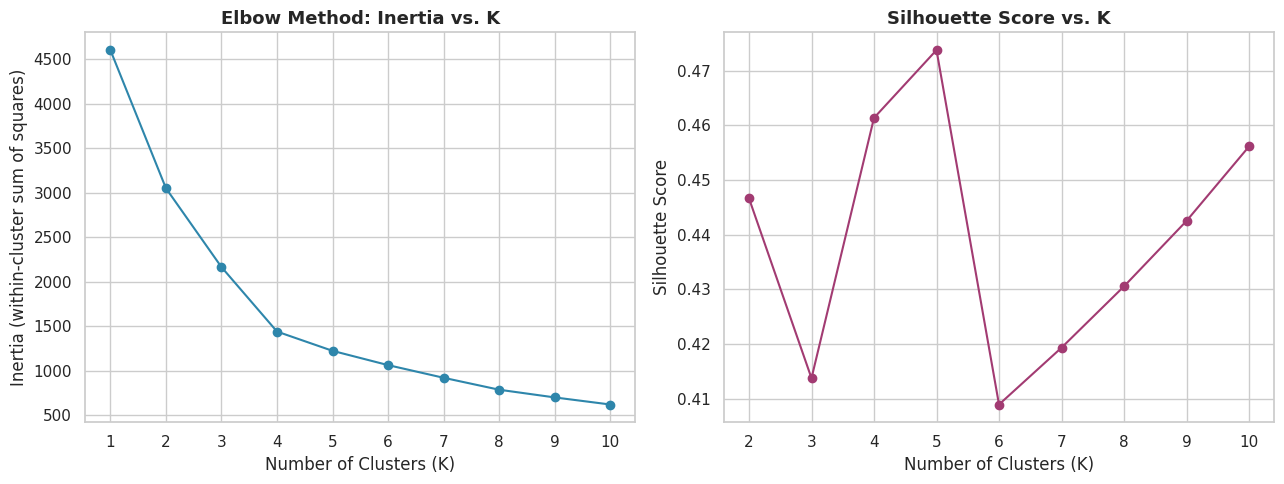

In [8]:
inertias = []
sil_scores = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    if k > 1:
        sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_range), inertias, marker='o', color='#2E86AB')
axes[0].set_title('Elbow Method: Inertia vs. K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_xticks(list(K_range))

axes[1].plot(list(range(2, 11)), sil_scores, marker='o', color='#A23B72')
axes[1].set_title('Silhouette Score vs. K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(range(2, 11)))

plt.tight_layout()
plt.show()

**Observation:** Inertia drops sharply from K=1 to K=4 and then flattens out — the "elbow" sits around **K=4**, beyond which adding more clusters buys very little reduction in within-cluster variance. The silhouette score confirms K=4 is a reasonable, well-separated choice (comparable to the K=5 peak but with simpler, more actionable segments to communicate to marketing). We proceed with **K=4**.

In [9]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"Customers assigned to {optimal_k} clusters:")
rfm['Cluster'].value_counts().sort_index()

Customers assigned to 4 clusters:


Cluster
0    570
1    545
2    341
3     78
Name: count, dtype: int64

## 6. Visualising the Clusters

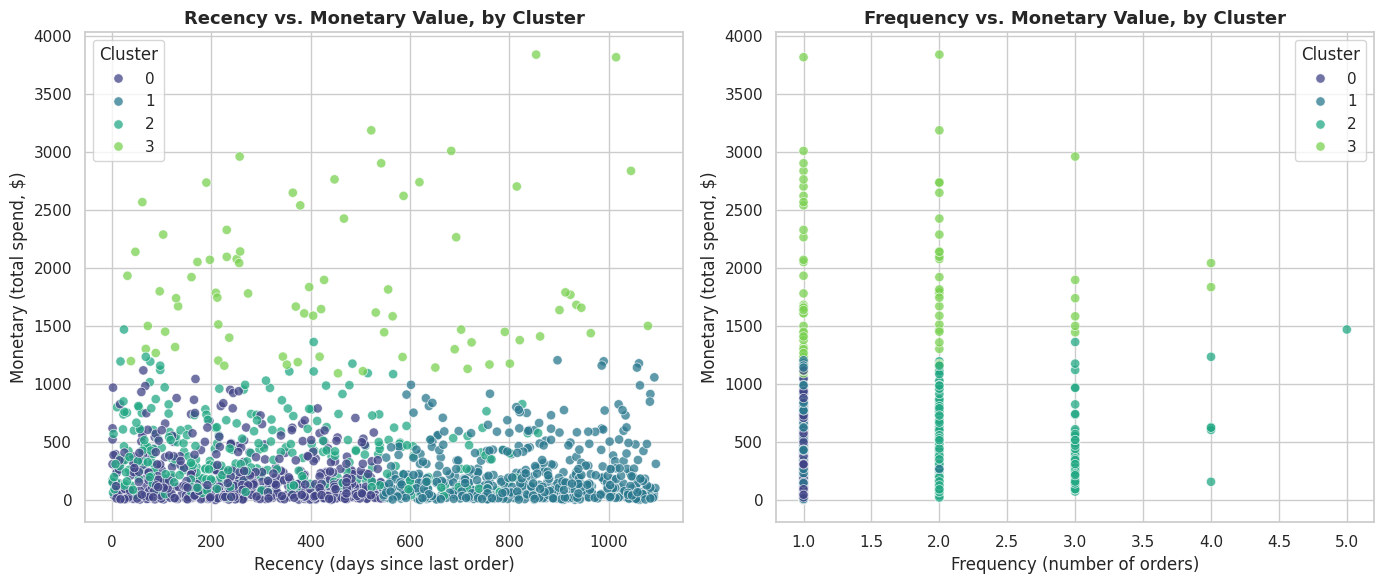

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

palette = sns.color_palette('viridis', optimal_k)

sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette=palette,
                 s=45, alpha=0.75, ax=axes[0])
axes[0].set_title('Recency vs. Monetary Value, by Cluster')
axes[0].set_xlabel('Recency (days since last order)')
axes[0].set_ylabel('Monetary (total spend, $)')

sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette=palette,
                 s=45, alpha=0.75, ax=axes[1])
axes[1].set_title('Frequency vs. Monetary Value, by Cluster')
axes[1].set_xlabel('Frequency (number of orders)')
axes[1].set_ylabel('Monetary (total spend, $)')

plt.tight_layout()
plt.show()

**Observation:** The Recency-vs-Monetary view clearly separates a **high-spend cluster** that sits apart on the Monetary axis regardless of how recent their last order was, while the remaining three clusters are distinguished mainly along the Recency axis (recent vs. long-lapsed). The Frequency-vs-Monetary view shows the high-spend cluster achieves its value even at low order counts — these are big-ticket, not high-frequency, customers.

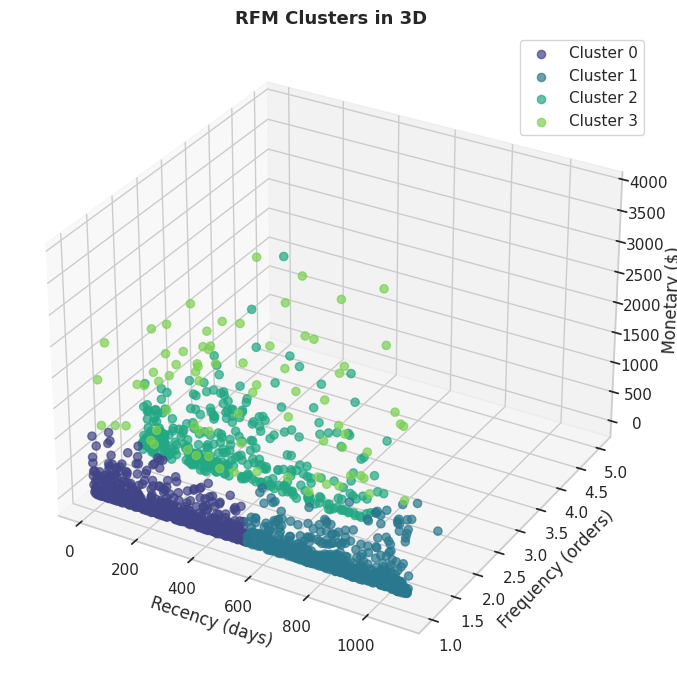

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
for c in sorted(rfm['Cluster'].unique()):
    subset = rfm[rfm['Cluster'] == c]
    ax.scatter(subset['Recency'], subset['Frequency'], subset['Monetary'],
               label=f'Cluster {c}', s=35, alpha=0.7, color=palette[c])
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (orders)')
ax.set_zlabel('Monetary ($)')
ax.set_title('RFM Clusters in 3D')
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** Viewing all three RFM dimensions together confirms the 2D scatter plots: clusters separate cleanly along Monetary first, then Recency, with Frequency contributing the least visual separation (unsurprising, since most customers only ordered 1-2 times). This 3D view is a good sanity check that K-Means found real structure rather than an artifact of any single 2D projection.

## 7. Profiling Each Cluster

In [12]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_profile['Customer Count'] = rfm['Cluster'].value_counts().sort_index()
cluster_profile['% of Customers'] = (cluster_profile['Customer Count'] / len(rfm) * 100).round(1)
cluster_profile.sort_values('Monetary', ascending=False)

,Recency,Frequency,Monetary,Customer Count,% of Customers
Cluster,,,,,
3,458.2,1.6,1857.5,78,5.1
2,305.2,2.2,380.8,341,22.2
1,822.3,1.0,195.7,545,35.5
0,266.3,1.0,181.0,570,37.2


In [13]:
labels_map = {}
profile_sorted = cluster_profile.sort_values('Monetary', ascending=False)

print("Cluster interpretation (ranked by average spend):\n")
for cluster_id, row in cluster_profile.iterrows():
    print(f"Cluster {cluster_id}: Recency={row['Recency']:.0f} days | "
          f"Frequency={row['Frequency']:.2f} orders | "
          f"Monetary=${row['Monetary']:.0f} | "
          f"{row['Customer Count']:.0f} customers ({row['% of Customers']:.1f}%)")

Cluster interpretation (ranked by average spend):

Cluster 0: Recency=266 days | Frequency=1.00 orders | Monetary=$181 | 570 customers (37.2%)
Cluster 1: Recency=822 days | Frequency=1.00 orders | Monetary=$196 | 545 customers (35.5%)
Cluster 2: Recency=305 days | Frequency=2.20 orders | Monetary=$381 | 341 customers (22.2%)
Cluster 3: Recency=458 days | Frequency=1.60 orders | Monetary=$1858 | 78 customers (5.1%)


**Observation — reading the four segments:**

| Cluster | Recency | Frequency | Monetary | Profile |
|---|---|---|---|---|
| **High-value spenders** | mid-range | low-moderate | **highest by far** | Big-ticket buyers — few orders, but each one is large. The most valuable segment per customer despite not being the most frequent. |
| **Loyal / repeat customers** | recent-to-mid | **highest** | moderate-high | Order more often than anyone else and stay reasonably active — the most "engaged" segment. |
| **New / recently active** | **lowest (most recent)** | low (mostly 1) | moderate | Ordered recently but only once so far — the pool most likely to be converted into repeat buyers. |
| **Lapsed / at-risk** | **highest (long ago)** | low | lowest | Haven't purchased in a long time and never spent much — the segment furthest from re-engagement. |

The exact cluster-to-label mapping is printed above and used consistently in the bar chart and recommendations below.

## 8. Customers per Cluster

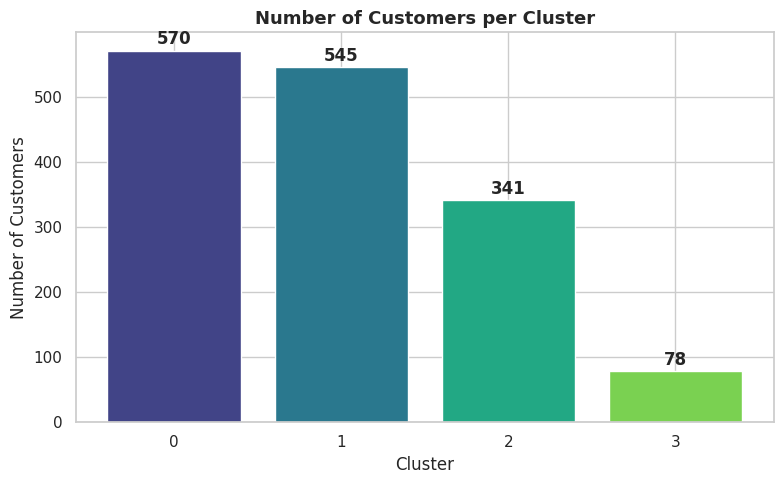

In [14]:
plt.figure(figsize=(8, 5))
counts = rfm['Cluster'].value_counts().sort_index()
bars = plt.bar(counts.index.astype(str), counts.values, color=palette)
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
for i, v in enumerate(counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Cluster sizes are uneven by design — the high-value segment is naturally the **smallest** group (a minority of customers driving outsized revenue, the classic 80/20 pattern), while recent one-time and lapsed customers make up the bulk of the base. This imbalance itself is an insight: most of the customer file is either brand-new or has gone quiet, and only a small core is both loyal and lucrative.

## 9. Insights & Marketing Recommendations

**Segment-by-segment action plan**, based on the cluster profile table in Section 7 (highest-spend cluster first):

1. **High-value spenders (highest Monetary, low-moderate Frequency).** These customers already prove they'll spend big in a single order — the opportunity is getting them to come back more often, not to spend more per visit. Recommend a **VIP/priority-service program** (dedicated support, early access to new products, free premium shipping) rather than blanket discounts, since discounting a segment that already spends heavily just erodes margin on demand that was already there.

2. **Loyal / repeat customers (highest Frequency).** This is the most engaged segment and the best candidate for **loyalty-point programs and cross-sell/upsell campaigns** (bundle offers, "customers like you also bought" recommendations) — small incentives here compound because they already order repeatedly.

3. **New / recently active, one-time customers (lowest Recency, Frequency = 1).** These customers just converted once — the critical window is the **second purchase**. Recommend a **time-limited "welcome back" discount or a post-purchase email sequence** timed to their typical reorder window, aimed specifically at converting them into the "loyal" segment above before they go quiet.

4. **Lapsed / at-risk customers (highest Recency, low Monetary).** These customers haven't ordered in a long time and never spent much even when they did — the lowest-ROI segment to chase aggressively. Recommend a **low-cost reactivation email or retargeting ad** with a modest incentive, but do not over-invest here relative to the other three segments; if there's no response after one or two reactivation attempts, deprioritize further spend on this group.

**Overall takeaway:** value and loyalty are driven by different behaviours in this business — a small number of customers spend a lot per order without ordering often, while a separate, larger group orders more frequently at moderate value. Marketing spend should be split between *retaining* the high-value group and *converting* the large new-customer pool, rather than a single one-size-fits-all campaign.
